In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from copy import deepcopy

from openquake.hazardlib.imt import PGA, SA, RSD595, AvgSA, IMT

from pickagm.distributions import (
    ensemble_ecdfs, 
    ensemble_quantiles,
    ensemble_ks_test,
    ensemble_r_score,
    ensemble_ks_bounds
    )

from phd_project.config import config
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    ESHM20SiteRupCtxBuilder,
    create_gmm_map,
    create_corr_model_map,
    get_ground_motion_ensembles_for_sites,
    adjust_ensemble_distributions,
    greedy_optimise_ensemble,
    sse_point_stats,
    weighted_ks_statistic,
    weighted_ks_statistic_and_failing_im_penalty,
    total_ks_statistic,
    total_ks_statistic_and_failing_im_penalty
)
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
from phd_project.plotting import custom_log_formatter

cfg = config.load_config()

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [14]:
# load the site file
sites = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])

# load the flatfiles
flatfile_folder = cfg["proc_data"]["corr_model"] / "reverse" / "flatfiles"
flatfiles = {}
for f in [f for f in os.listdir(flatfile_folder) if f.endswith(".csv")]:
    tag = f.split("_")[0]
    flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0, low_memory=False)

flatfiles["volcanic"] = pd.read_csv(cfg["raw_data"]["gm_flatfiles"] / "volcanic_lanzanoluzi_flatfile.csv", 
                                    delimiter=";", index_col=0)

# load the preprocessed gm database
gm_database = pd.read_csv(cfg["proc_data"]["gm_database"], sep=",", low_memory=False, header=[0, 1])

# load disaggregation data
fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data = pickle.load(f)

# create the average depth map for each TRT
average_depths = {
    "Craton": flatfiles["asc"]["ev_depth_km"].mean(),
    "Non-Subduction Deep": flatfiles["vran"]["ev_depth_km"].mean(),
    "Shallow Default": flatfiles["asc"]["ev_depth_km"].mean(),
    "Subduction Inslab": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Subduction Interface": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Volcanic": flatfiles["volcanic"]["ev_depth_km"].mean(),
}

# the map of what sim trts are allowed to match with what record trts
OK_TRT_MATCHES = {
    "Craton": ["Shallow Default"],
    "Non-Subduction Deep": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Shallow Default": ["Shallow Default"],
    "Subduction Inslab": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Subduction Interface": ["Subduction Interface"],
    "Volcanic": ["Shallow Default"],
}

occurence = True    # the record selection should be performed based on occurence


# set some parameters for the selection
t_lower = 0.025     # lower SA period considered in selection
t_upper = 6         # upper SA period considered in selection
n_periods = 20      # number of periods to consider in selection

conditioning_imt: IMT = AvgSA([0,6])                      
nonSA_imts: list[IMT] = [AvgSA([0,6]), RSD595(), PGA()] 
sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
SA_imts: list[IMT] = [SA(period) for period in sa_periods]
selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts    # not AvgSA but the others (PGA and RSD595)
nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# weights of the IMs
weight_rsd595 = 0.1
n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
                        else weight_rsd595 for imt in selection_imts])
imt_weights /= imt_weights.sum()

# some other things
disagg_type = "TRT_Mag_Dist_Eps"
percentiles = [0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95]     # percentiles of the gcim distribution to return  
assumed_rake = -90                                # assumed rake for RSD595 calculation

# filter the gm_database so that only the selection and conditioning ims are present
gm_db = gm_database.copy()
updated_ims = mf.filter_gm_database_on_imts(
    gm_db["ims"], selection_imts + [conditioning_imt])
updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
gm_db = pd.concat([gm_db.drop('ims', axis=1, level=0), updated_ims], axis=1)

# Create the GMM Map for AvgSA by reading the logic tree
AvgSA_06_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to6_median_branch.xml"
gmm_map = create_gmm_map(AvgSA_06_lt_fp)

# get the correlation model map
corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

# organise the disagg data
site_poe_disaggs = {}
for (s, r) in disagg_data.keys():
    for site in disagg_data[(s,r)].keys():
        for poe in disagg_data[(s,r)][site][conditioning_imt.name].keys():
            site_poe_disaggs[(site, poe)] = disagg_data[(s,r)][site][conditioning_imt.name][poe]
site_poes = sorted(list(site_poe_disaggs.keys()), key=lambda x: x[0])

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats= pickle.load(f)

# load the gcim distribution data
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06_rake{int(assumed_rake)}.pickle"
with open(gcim_dist_fp, "rb") as file:
    gcim_dists = pickle.load(file)

# Record Selection

In [44]:
basic_selection_ctx = {
    "n_ensembles": 20,
    "n_samples": 30,
    "conditioning_imt": conditioning_imt ,
    "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
    "selection_imts": selection_imts ,
    "imt_weights": imt_weights ,
    "sites": sites ,
    "ctx_builder": ESHM20SiteRupCtxBuilder ,
    "ctx_builder_params": ["average_depths", "assumed_rake"] ,
    "average_depths": average_depths ,
    "assumed_rake": assumed_rake ,
    "gmm_map": gmm_map ,
    "corr_map": corr_map ,
    "m_bound_model": "tarbali_and_bradley_2016" ,
    "d_bound_model": "tarbali_and_bradley_2016" ,
    "vs30_bound_model": "tarbali_and_bradley_2016" ,
    "sf_bounds": (0.04, 30),
    "usable_T": t_upper ,
    "max_n_recs": 5 ,
    "p_value": 0.05 ,
    "ok_trt_matches": OK_TRT_MATCHES ,
    "occurence": True ,
}

rng_seed = 4

In [ ]:
site = 4
poe = 0.0001
only_select = [(site, poe)]

candidate_ensembles = get_ground_motion_ensembles_for_sites(
    site_poe_disaggs, disagg_stats, gcim_dists, 
    gm_db, basic_selection_ctx, sites, rng_seed, only_select)
    
# # get the best of the candidate ensembles and save
# obj_func = total_ks_statistic_and_failing_im_penalty

# preliminary_ensembles = {}

# for (site, poe), ensembles in candidate_ensembles.items():
#     target_cdfs = gcim_dists[(site, poe)]["cdfs"]
#     ks_bounds = ensemble_ks_bounds(
#         target_cdfs, 
#         basic_selection_ctx["n_samples"],
#         basic_selection_ctx["p_value"])
    
#     obj_func_kwargs = {
#         "target_cdfs_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,2]]) 
#                             for ksb in ks_bounds.values()],
#         "upper_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,3]]) 
#                                 for ksb in ks_bounds.values()],
#         "lower_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,1]]) 
#                                 for ksb in ks_bounds.values()],
#         "n_recs": basic_selection_ctx["n_samples"],
#         "penalty_constant": 10
#     }

#     e = get_best_ensemble_in_list(
#         ensembles, basic_selection_ctx["conditioning_imt"].string, 
#         obj_func, obj_func_kwargs)
#     preliminary_ensembles[(site, poe)] = e



# # Check if all the sites and poes found a set of suitable ground motions
# prelim_ensembles_not_passing = []
# for (site, poe), ensemble in preliminary_ensembles.items():
#     if not ensemble["ks_passed"]:
#         prelim_ensembles_not_passing.append((site, poe))

# if len(prelim_ensembles_not_passing) == 0:
#     print(f"OK! - Preliminary ensembles pass for all combinations of site and poe")
# else:
#     print(f"Sub-Optimal! - Preliminary ensembles do not pass for {len(prelim_ensembles_not_passing)} combinations of site and poe")

Selecting GM Ensembles:   0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
for e in candidate_ensembles[(site, poe)]:
    print(e["ks_passed"], e["ks_failed_ims"])

False ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.188)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.597)', 'SA(0.797)', 'SA(1.063)', 'SA(1.893)', 'SA(6.0)']
False ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.597)', 'SA(0.797)', 'SA(1.063)', 'SA(1.893)', 'SA(6.0)']
False ['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.335)', 'SA(0.447)', 'SA(0.797)', 'SA(1.893)', 'SA(2.525)', 'SA(6.0)']
False ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.597)', 'SA(0.797)', 'SA(1.063)', 'SA(1.893)', 'SA(2.525)', 'SA(6.0)']
False ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.597)', 'SA(0.797)', 'SA(1.063)', 'SA(1.893)', 'SA(2.525)', 'SA(6.0)']
False ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.797)', 'SA(6.0)']
False ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.251)', 'SA(0.3

In [47]:
candidate_ensembles[(site, poe)][0]["sims"]

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
RSD595,34.842928,36.619551,38.465990,14.629633,18.335505,36.325416,46.281839,23.126772,86.796426,38.752623,...,21.810995,24.891002,62.117663,40.685172,24.529398,21.784161,28.353291,53.726496,18.855940,19.486672
PGA,0.091186,0.090234,0.077459,0.267311,0.071185,0.089761,0.107706,0.139805,0.072021,0.089622,...,0.090052,0.175247,0.063172,0.111164,0.161011,0.124980,0.127772,0.062722,0.155463,0.094686
SA(0.025),0.100563,0.098544,0.077241,0.268452,0.068879,0.094514,0.113749,0.143423,0.069204,0.087061,...,0.088312,0.200451,0.064302,0.112939,0.160235,0.130866,0.134272,0.061509,0.140975,0.093320
SA(0.033),0.111596,0.090979,0.077802,0.249158,0.062727,0.096816,0.108919,0.144629,0.072440,0.091328,...,0.083615,0.208178,0.068786,0.122961,0.149625,0.134164,0.156327,0.062203,0.151756,0.097459
SA(0.045),0.102232,0.096608,0.096281,0.312809,0.063055,0.097427,0.106084,0.152408,0.073067,0.105642,...,0.079631,0.239072,0.062158,0.121514,0.143440,0.131267,0.165004,0.058240,0.149596,0.087044
SA(0.059),0.108409,0.093493,0.098436,0.346286,0.063443,0.116006,0.086599,0.155939,0.076843,0.096238,...,0.084669,0.251721,0.070175,0.133376,0.168663,0.146021,0.183069,0.076788,0.176968,0.092771
SA(0.079),0.108586,0.116111,0.104353,0.351811,0.086582,0.125390,0.097543,0.163891,0.093547,0.126958,...,0.086801,0.270678,0.075586,0.130849,0.213807,0.169560,0.159966,0.076125,0.235480,0.090289
SA(0.106),0.123414,0.098990,0.120581,0.560779,0.104836,0.117726,0.148345,0.190874,0.104183,0.105284,...,0.108493,0.273820,0.090771,0.155862,0.279707,0.160266,0.212493,0.116799,0.235228,0.112695
SA(0.141),0.104621,0.118611,0.108500,0.587578,0.125333,0.140168,0.150009,0.272968,0.073178,0.126899,...,0.151943,0.255293,0.105297,0.177402,0.310805,0.245566,0.265754,0.141179,0.422164,0.152748
SA(0.188),0.127491,0.152351,0.107305,0.734182,0.167993,0.111401,0.231194,0.295715,0.120392,0.160890,...,0.122833,0.285958,0.099157,0.221689,0.303727,0.272457,0.262973,0.100278,0.340272,0.153669


In [48]:
target_cdfs = gcim_dists[(site, poe)]["cdfs"]
for e in candidate_ensembles[(site, poe)]:
    ks_passed, ks_results, failing_ims = ensemble_ks_test(e["sims"].T, target_cdfs, p_val=0.05)
    print(failing_ims)

[]
[]
['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.141)', 'SA(0.188)']
['SA(0.025)', 'SA(0.033)', 'SA(3.37)', 'SA(4.497)', 'SA(6.0)']
[]
[]
[]
[]
[]
['PGA', 'SA(0.025)']
['SA(0.797)', 'SA(1.063)', 'SA(1.418)', 'SA(4.497)']
[]
[]
[]
[]
['SA(0.447)', 'SA(0.597)']
[]
['SA(0.335)', 'SA(0.597)', 'SA(2.525)', 'SA(3.37)']
['PGA']
['PGA', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.141)']


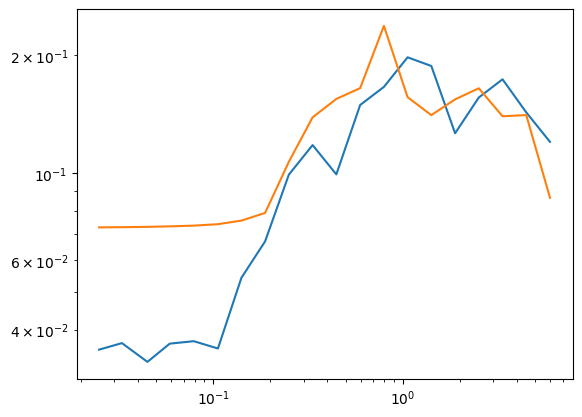

In [52]:
ii =4
ensemble = candidate_ensembles[(site, poe)][ii]

fig, ax = plt.subplots()

sa_keys = [sa.string for sa in SA_imts]

ax.loglog(sa_periods, ensemble["sims"].iloc[:, ii][sa_keys].to_numpy(), label="sim")
ax.loglog(sa_periods, ensemble["recs"]["ims_scaled"].iloc[ii, :][sa_keys].to_numpy(), label="rec")

In [50]:
ensemble["recs"]


metadata                                                       \
         index database               event_id           event_time   
10194    11356      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
10189    11351      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
31347    11361      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
20146    21994      ESM           TK-1999-0077  1999-08-17 00:01:38   
31333    11347      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
10171    11333      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
20884    22748      ESM           IR-1997-0030  1997-05-10 07:57:29   
16263    18048      ESM           IT-2012-0008  2012-05-20 02:03:50   
20150    21998      ESM           TK-1999-0077  1999-08-17 00:01:38   
37326    17963      ESM           IT-2012-0008  2012-05-20 02:03:50   
37441    18078      ESM           IT-2012-0008  2012-05-20 02:03:50   
20134    21982      ESM           TK-1999-0077  1999-08-17 00:01:38   
42031    22748      ESM           IR-1997-0030  1997-05-10 07:57:29   
20159    22007      ESM           TK-1999-0077  1999-08-17 00:01:38   
16237    18022      ESM           IT-2012-0008  2012-05-20 02:03:50   
16178    17963      ESM           IT-2012-0008  2012-05-20 02:03:50   
41388    22089      ESM           TK-1999-0415  1999-11-12 16:57:19   
42034    22751      ESM           IR-1997-0030  1997-05-10 07:57:29   
20158    22006      ESM           TK-1999-0077  1999-08-17 00:01:38   
20260    22109      ESM           TK-1999-0415  1999-11-12 16:57:19   
41406    22108      ESM           TK-1999-0415  1999-11-12 16:57:19   
41395    22096      ESM           TK-1999-0415  1999-11-12 16:57:19   
41412    22115      ESM           TK-1999-0415  1999-11-12 16:57:19   
27666     7339      ESM  EMSC-20151117_0000025  2015-11-17 07:10:08   
33807    14427      ESM           IT-1980-0012  1980-11-23 18:34:53   
12659    14427      ESM           IT-1980-0012  1980-11-23 18:34:53   
42080    22797      ESM           IR-2002-0035  2002-06-22 02:58:21   
20887    22751      ESM           IR-1997-0030  1997-05-10 07:57:29   
27667     7340      ESM  EMSC-20151117_0000025  2015-11-17 07:10:08   
33809    14429      ESM           IT-1980-0012  1980-11-23 18:34:53   

                                                                              \
      station_code location_code              trt   mag     rjb         vs30   
10194          FRT             0  Shallow Default  6.50  112.30   837.122623   
10189          FLT             0  Shallow Default  6.50   90.49   997.948216   
31347          GRN             0  Shallow Default  6.50   99.23  1017.544205   
20146          YPT             0  Shallow Default  7.40    6.44   452.416002   
31333          DUR             0  Shallow Default  6.50  153.27   727.291194   
10171          CMB             0  Shallow Default  6.50  172.01   834.594131   
20884          MSV             0  Shallow Default  6.80  101.31   467.037159   
16263         BRIS             0  Shallow Default  6.10   67.58   997.338421   
20150         1001             0  Shallow Default  7.40  185.46   662.000000   
37326          CSP             0  Shallow Default  6.10   46.77   443.995465   
37441         MTRZ             0  Shallow Default  6.10   52.96   548.958640   
20134          ARC             0  Shallow Default  7.40   22.94   483.561448   
42031          MSV             0  Shallow Default  6.80  101.31   467.037159   
20159         4106             0  Shallow Default  7.40   14.57   701.000000   
16237          SNM             0  Shallow Default  6.10  123.96   889.599638   
16178          CSP             0  Shallow Default  6.10   46.77   443.995465   
41388          BAG             0  Shallow Default  7.10  134.47   424.934272   
42034          SRY             0  Shallow Default  6.80  114.28   438.971690   
20158         4101             0  Shallow Default  7.40    7.12   827.000000   
20260          RUZ             0  Shallow Default  7.

In [51]:
import numpy as np
from scipy import stats

def check_ks_failure_rate(n_samples=30, n_trials=1000, alpha=0.05):
    failures = 0
    
    for _ in range(n_trials):
        # Simulate IMs from a distribution (e.g., Log-normal or Normal)
        data = np.random.normal(0, 1, n_samples)
        
        # K-S test against the theoretical distribution
        stat, p_val = stats.ks_1samp(data, stats.norm.cdf)
        
        if p_val < alpha:
            failures += 1
            
    return (failures / n_trials) * 100

rate = check_ks_failure_rate()
print(f"Observed Failure Rate: {rate:.2f}%")

Observed Failure Rate: 4.70%
